In [1]:
# ALAZ Solar Alert — 02_ALAZ_EDA_and_Feature_Engineering
# Purpose:
#   - exploratory data analysis
#   - feature engineering
#   - training dataset generation for model development

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

# --- Dynamic path resolution ---
current_path = os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(current_path, "..")) if "notebooks" in current_path else current_path
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")

master_path = os.path.join(PROCESSED_DIR, "ALAZ_HighRes_Training_Data.csv")
engineered_train_path = os.path.join(PROCESSED_DIR, "ALAZ_Engineered_Training_Data.csv")

print(f"Loading master dataset from: {master_path}")

if not os.path.exists(master_path):
    raise FileNotFoundError(f"Master dataset not found: {master_path}")

Loading master dataset from: C:\Users\DELL\Desktop\astro\data\processed\ALAZ_HighRes_Training_Data.csv


In [2]:
# Load corrected master dataset from notebook 01
df_alaz = pd.read_csv(master_path)

required_cols = [
    "SAT_NAME", "NORAD_ID", "EPOCH", "DATE",
    "BSTAR", "MEAN_MOTION", "PERIOD",
    "KP_INDEX", "ISN", "F10.7_OBS", "F10.7_ADJ"
]

missing_cols = [c for c in required_cols if c not in df_alaz.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in master dataset: {missing_cols}")

# Type casting
df_alaz["EPOCH"] = pd.to_datetime(df_alaz["EPOCH"], errors="coerce")
df_alaz["DATE"] = pd.to_datetime(df_alaz["DATE"], errors="coerce")
df_alaz["NORAD_ID"] = df_alaz["NORAD_ID"].astype(str).str.strip()

numeric_cols = ["BSTAR", "MEAN_MOTION", "PERIOD", "KP_INDEX", "ISN", "F10.7_OBS", "F10.7_ADJ"]
for col in numeric_cols:
    df_alaz[col] = pd.to_numeric(df_alaz[col], errors="coerce")

df_alaz = df_alaz.dropna(subset=["NORAD_ID", "EPOCH"]).copy()
df_alaz = df_alaz.sort_values(["NORAD_ID", "EPOCH"]).reset_index(drop=True)

print("Master dataset loaded successfully.")
print(f"Shape           : {df_alaz.shape}")
print(f"Satellites      : {df_alaz['NORAD_ID'].nunique()}")
print(f"Epoch range     : {df_alaz['EPOCH'].min()} -> {df_alaz['EPOCH'].max()}")
print(f"Duplicate rows  : {df_alaz.duplicated(subset=['NORAD_ID', 'EPOCH']).sum()}")

Master dataset loaded successfully.
Shape           : (32640, 11)
Satellites      : 39
Epoch range     : 2025-01-01 00:01:28.758720 -> 2026-03-28 14:32:26.845728
Duplicate rows  : 0


In [3]:
print("=== Null counts in required columns ===")
print(df_alaz[required_cols].isnull().sum())

dups = df_alaz.duplicated(subset=["NORAD_ID", "EPOCH"]).sum()
print(f"\nDuplicate (NORAD_ID, EPOCH) rows: {dups}")

if dups > 0:
    df_alaz = df_alaz.drop_duplicates(subset=["NORAD_ID", "EPOCH"]).reset_index(drop=True)
    print(f"Duplicates removed. New shape: {df_alaz.shape}")

=== Null counts in required columns ===
SAT_NAME         0
NORAD_ID         0
EPOCH            0
DATE             0
BSTAR            0
MEAN_MOTION      0
PERIOD           0
KP_INDEX       131
ISN            131
F10.7_OBS      131
F10.7_ADJ      131
dtype: int64

Duplicate (NORAD_ID, EPOCH) rows: 0


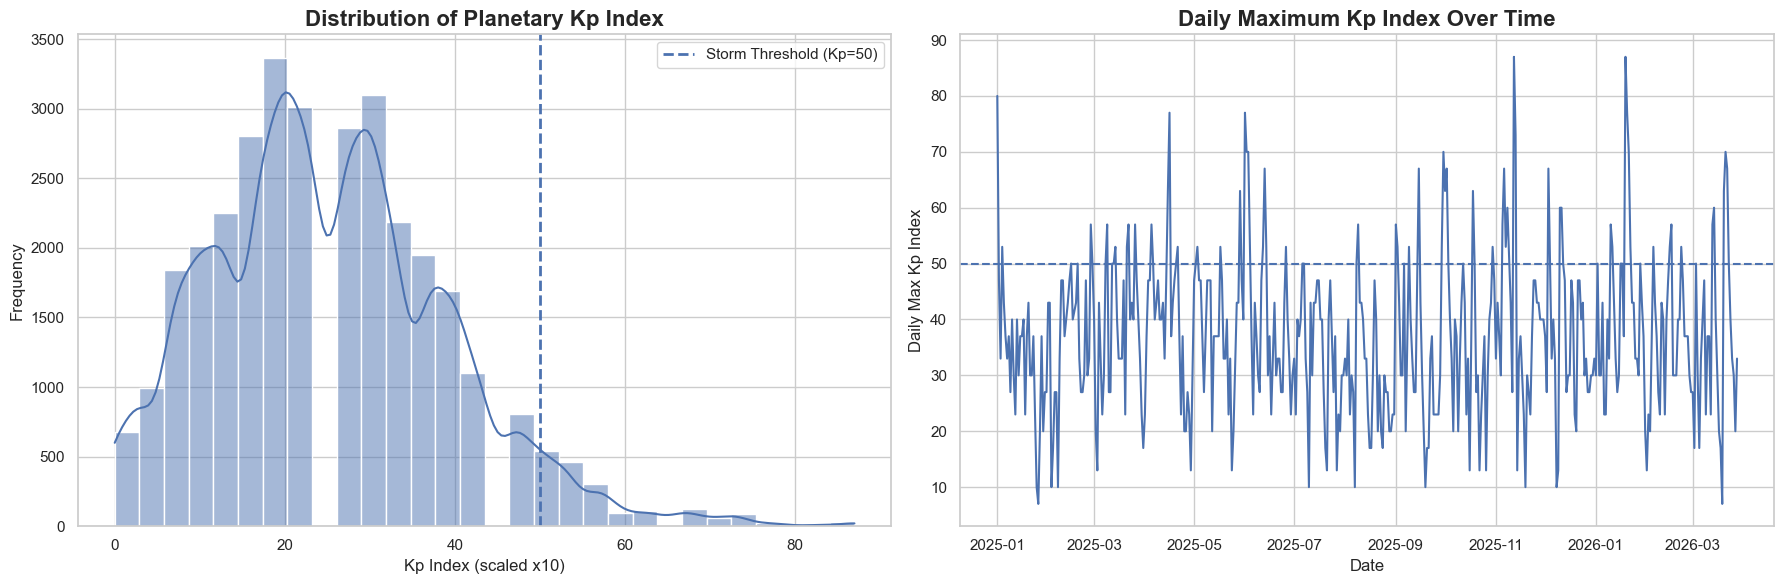

In [4]:
# ---------------------------------------------------------
# EDA 1: Space weather signal inspection
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(data=df_alaz, x="KP_INDEX", bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Planetary Kp Index", fontweight="bold")
axes[0].set_xlabel("Kp Index (scaled x10)")
axes[0].set_ylabel("Frequency")
axes[0].axvline(x=50, linestyle="--", linewidth=2, label="Storm Threshold (Kp=50)")
axes[0].legend()

daily_max_kp = (
    df_alaz.groupby(df_alaz["DATE"].dt.date)["KP_INDEX"]
    .max()
    .reset_index()
)

sns.lineplot(data=daily_max_kp, x="DATE", y="KP_INDEX", ax=axes[1], linewidth=1.5)
axes[1].set_title("Daily Maximum Kp Index Over Time", fontweight="bold")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Daily Max Kp Index")
axes[1].axhline(y=50, linestyle="--", linewidth=1.5)

plt.tight_layout()
plt.show()

In [5]:
# ---------------------------------------------------------
# Build a unique shared time-axis for space weather variables
# NOAA-derived variables are shared across satellites at DATE + PERIOD level.
# Therefore, the correct unique timeline is DATE + PERIOD-based.
# ---------------------------------------------------------
sw_time = (
    df_alaz[
        ["DATE", "PERIOD", "KP_INDEX", "ISN", "F10.7_OBS", "F10.7_ADJ"]
    ]
    .copy()
)

# Ensure proper types
sw_time["DATE"] = pd.to_datetime(sw_time["DATE"], errors="coerce")
sw_time["PERIOD"] = pd.to_numeric(sw_time["PERIOD"], errors="coerce")

sw_cols = ["KP_INDEX", "ISN", "F10.7_OBS", "F10.7_ADJ"]

def first_non_null(series):
    s = series.dropna()
    return s.iloc[0] if not s.empty else np.nan

# Aggregate safely at shared DATE + PERIOD level
sw_time = (
    sw_time
    .groupby(["DATE", "PERIOD"], as_index=False)
    .agg({
        "KP_INDEX": first_non_null,
        "ISN": first_non_null,
        "F10.7_OBS": first_non_null,
        "F10.7_ADJ": first_non_null,
    })
)

# Create synthetic timestamp for true 3-hour ordering
# PERIOD 1->00:00, 2->03:00, ..., 8->21:00
sw_time["SW_TIMESTAMP"] = (
    sw_time["DATE"] +
    pd.to_timedelta((sw_time["PERIOD"] - 1) * 3, unit="h")
)

# Fill only on the shared chronological timeline
sw_time = sw_time.sort_values("SW_TIMESTAMP").reset_index(drop=True)
sw_time[sw_cols] = sw_time[sw_cols].ffill().bfill()

print("Shared space weather timeline prepared.")
print(f"Timeline shape: {sw_time.shape}")
print("\nRemaining null counts:")
print(sw_time[sw_cols].isnull().sum())

display(sw_time.head(12))

Shared space weather timeline prepared.
Timeline shape: (3406, 7)

Remaining null counts:
KP_INDEX     0
ISN          0
F10.7_OBS    0
F10.7_ADJ    0
dtype: int64


,DATE,PERIOD,KP_INDEX,ISN,F10.7_OBS,F10.7_ADJ,SW_TIMESTAMP
0,2025-01-01,1,40.0,198.0,219.2,211.9,2025-01-01 00:00:00
1,2025-01-01,2,53.0,198.0,219.2,211.9,2025-01-01 03:00:00
2,2025-01-01,3,50.0,198.0,219.2,211.9,2025-01-01 06:00:00
3,2025-01-01,4,60.0,198.0,219.2,211.9,2025-01-01 09:00:00
4,2025-01-01,5,67.0,198.0,219.2,211.9,2025-01-01 12:00:00
5,2025-01-01,6,80.0,198.0,219.2,211.9,2025-01-01 15:00:00
6,2025-01-01,7,63.0,198.0,219.2,211.9,2025-01-01 18:00:00
7,2025-01-01,8,40.0,198.0,219.2,211.9,2025-01-01 21:00:00
8,2025-01-02,1,33.0,187.0,212.4,205.4,2025-01-02 00:00:00
9,2025-01-02,2,20.0,187.0,212.4,205.4,2025-01-02 03:00:00


In [6]:
# ---------------------------------------------------------
# Time-based space weather feature engineering
# Lags and rolling windows are computed on the true shared 3-hour timeline.
# ---------------------------------------------------------
sw_time = sw_time.sort_values("SW_TIMESTAMP").reset_index(drop=True)

# Kp lags (3-hour cadence)
sw_time["KP_LAG_3H"]  = sw_time["KP_INDEX"].shift(1)
sw_time["KP_LAG_6H"]  = sw_time["KP_INDEX"].shift(2)
sw_time["KP_LAG_12H"] = sw_time["KP_INDEX"].shift(4)
sw_time["KP_LAG_24H"] = sw_time["KP_INDEX"].shift(8)

# F10.7 lags
sw_time["F107_LAG_1D"] = sw_time["F10.7_OBS"].shift(8)
sw_time["F107_LAG_3D"] = sw_time["F10.7_OBS"].shift(24)

# Rolling features from past only
sw_time["KP_ROLLING_24H_MEAN"] = sw_time["KP_INDEX"].shift(1).rolling(window=8, min_periods=1).mean()
sw_time["KP_ROLLING_24H_MAX"]  = sw_time["KP_INDEX"].shift(1).rolling(window=8, min_periods=1).max()
sw_time["KP_ROLLING_48H_MEAN"] = sw_time["KP_INDEX"].shift(1).rolling(window=16, min_periods=1).mean()

sw_time["F107_ROLLING_3D_MEAN"] = sw_time["F10.7_OBS"].shift(1).rolling(window=24, min_periods=1).mean()

# Threshold flags
sw_time["KP_GE_40"] = (sw_time["KP_INDEX"] >= 40).astype(int)
sw_time["KP_GE_50"] = (sw_time["KP_INDEX"] >= 50).astype(int)
sw_time["KP_GE_70"] = (sw_time["KP_INDEX"] >= 70).astype(int)

sw_time["F107_HIGH"] = (sw_time["F10.7_OBS"] >= 150).astype(int)
sw_time["F107_VERY_HIGH"] = (sw_time["F10.7_OBS"] >= 200).astype(int)

display(
    sw_time[
        [
            "DATE", "PERIOD", "SW_TIMESTAMP",
            "KP_INDEX", "KP_LAG_3H", "KP_LAG_6H", "KP_LAG_12H", "KP_LAG_24H",
            "F10.7_OBS", "F107_LAG_1D", "F107_LAG_3D",
            "KP_ROLLING_24H_MEAN", "KP_ROLLING_24H_MAX", "KP_ROLLING_48H_MEAN",
            "F107_ROLLING_3D_MEAN"
        ]
    ].head(12)
)

,DATE,PERIOD,SW_TIMESTAMP,KP_INDEX,KP_LAG_3H,KP_LAG_6H,KP_LAG_12H,KP_LAG_24H,F10.7_OBS,F107_LAG_1D,F107_LAG_3D,KP_ROLLING_24H_MEAN,KP_ROLLING_24H_MAX,KP_ROLLING_48H_MEAN,F107_ROLLING_3D_MEAN
0,2025-01-01,1,2025-01-01 00:00:00,40.0,NaN,NaN,NaN,NaN,219.2,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01,2,2025-01-01 03:00:00,53.0,40.0,NaN,NaN,NaN,219.2,NaN,NaN,40.000000,40.0,40.000000,219.200000
2,2025-01-01,3,2025-01-01 06:00:00,50.0,53.0,40.0,NaN,NaN,219.2,NaN,NaN,46.500000,53.0,46.500000,219.200000
3,2025-01-01,4,2025-01-01 09:00:00,60.0,50.0,53.0,NaN,NaN,219.2,NaN,NaN,47.666667,53.0,47.666667,219.200000
4,2025-01-01,5,2025-01-01 12:00:00,67.0,60.0,50.0,40.0,NaN,219.2,NaN,NaN,50.750000,60.0,50.750000,219.200000
5,2025-01-01,6,2025-01-01 15:00:00,80.0,67.0,60.0,53.0,NaN,219.2,NaN,NaN,54.000000,67.0,54.000000,219.200000
6,2025-01-01,7,2025-01-01 18:00:00,63.0,80.0,67.0,50.0,NaN,219.2,NaN,NaN,58.333333,80.0,58.333333,219.200000
7,2025-01-01,8,2025-01-01 21:00:00,40.0,63.0,80.0,60.0,NaN,219.2,NaN,NaN,59.000000,80.0,59.000000,219.200000
8,2025-01-02,1,2025-01-02 00:00:00,33.0,40.0,63.0,67.0,40.0,212.4,219.2,NaN,56.625000,80.0,56.625000,219.200000
9,2025-01-02,2,2025-01-02 03:00:00,20.0,33.0,40.0,80.0,53.0,212.4,219.2,NaN,55.750000,80.0,54.000000,218.444444


In [7]:
# ---------------------------------------------------------
# Merge engineered space-weather features back into the main dataset
# Correct join key is DATE + PERIOD, not EPOCH.
# ---------------------------------------------------------
feature_cols_sw = [
    "DATE", "PERIOD",
    "KP_LAG_3H", "KP_LAG_6H", "KP_LAG_12H", "KP_LAG_24H",
    "F107_LAG_1D", "F107_LAG_3D",
    "KP_ROLLING_24H_MEAN", "KP_ROLLING_24H_MAX", "KP_ROLLING_48H_MEAN",
    "F107_ROLLING_3D_MEAN",
    "KP_GE_40", "KP_GE_50", "KP_GE_70",
    "F107_HIGH", "F107_VERY_HIGH"
]

# Ensure merge keys are aligned
df_alaz["DATE"] = pd.to_datetime(df_alaz["DATE"], errors="coerce")
df_alaz["PERIOD"] = pd.to_numeric(df_alaz["PERIOD"], errors="coerce")

df_alaz = df_alaz.merge(
    sw_time[feature_cols_sw],
    on=["DATE", "PERIOD"],
    how="left"
)

print("Space-weather engineered features merged correctly on DATE + PERIOD.")
print(f"New shape: {df_alaz.shape}")

check_cols = [
    "KP_LAG_3H", "KP_LAG_6H", "KP_LAG_12H", "KP_LAG_24H",
    "F107_LAG_1D", "F107_LAG_3D"
]
print("\nNull counts after merge:")
print(df_alaz[check_cols].isnull().sum())

Space-weather engineered features merged correctly on DATE + PERIOD.
New shape: (32640, 26)

Null counts after merge:
KP_LAG_3H        3
KP_LAG_6H        8
KP_LAG_12H      20
KP_LAG_24H      45
F107_LAG_1D     45
F107_LAG_3D    149
dtype: int64


In [8]:
# ---------------------------------------------------------
# Orbital / per-satellite feature engineering
# These features must be computed satellite by satellite.
# ---------------------------------------------------------
df_alaz = df_alaz.sort_values(["NORAD_ID", "EPOCH"]).reset_index(drop=True)
g = df_alaz.groupby("NORAD_ID", group_keys=False)

# Actual time gap between observations
df_alaz["TIME_DELTA_HOURS"] = g["EPOCH"].diff().dt.total_seconds() / 3600.0

# Lagged orbital variables
df_alaz["BSTAR_LAG_1"] = g["BSTAR"].shift(1)
df_alaz["BSTAR_LAG_2"] = g["BSTAR"].shift(2)

df_alaz["MEAN_MOTION_LAG_1"] = g["MEAN_MOTION"].shift(1)
df_alaz["MEAN_MOTION_LAG_2"] = g["MEAN_MOTION"].shift(2)

# Delta features
df_alaz["DELTA_BSTAR"] = df_alaz["BSTAR"] - df_alaz["BSTAR_LAG_1"]
df_alaz["DELTA_MEAN_MOTION"] = df_alaz["MEAN_MOTION"] - df_alaz["MEAN_MOTION_LAG_1"]

# Time-normalized deltas
df_alaz["BSTAR_CHANGE_PER_HOUR"] = df_alaz["DELTA_BSTAR"] / df_alaz["TIME_DELTA_HOURS"]
df_alaz["MEAN_MOTION_CHANGE_PER_HOUR"] = df_alaz["DELTA_MEAN_MOTION"] / df_alaz["TIME_DELTA_HOURS"]

# Rolling orbital features from past only
df_alaz["BSTAR_ROLLING_3_MEAN"] = g["BSTAR"].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
df_alaz["BSTAR_ROLLING_6_MEAN"] = g["BSTAR"].transform(lambda x: x.shift(1).rolling(6, min_periods=1).mean())

df_alaz["MM_ROLLING_3_MEAN"] = g["MEAN_MOTION"].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
df_alaz["MM_ROLLING_6_MEAN"] = g["MEAN_MOTION"].transform(lambda x: x.shift(1).rolling(6, min_periods=1).mean())

# Simple binary state flags
df_alaz["BSTAR_POSITIVE"] = (df_alaz["BSTAR"] > 0).astype(int)
df_alaz["BSTAR_INCREASE_FLAG"] = (df_alaz["DELTA_BSTAR"] > 0).astype(int)

display(df_alaz.head())

,SAT_NAME,NORAD_ID,EPOCH,DATE,BSTAR,MEAN_MOTION,PERIOD,KP_INDEX,ISN,F10.7_OBS,...,DELTA_BSTAR,DELTA_MEAN_MOTION,BSTAR_CHANGE_PER_HOUR,MEAN_MOTION_CHANGE_PER_HOUR,BSTAR_ROLLING_3_MEAN,BSTAR_ROLLING_6_MEAN,MM_ROLLING_3_MEAN,MM_ROLLING_6_MEAN,BSTAR_POSITIVE,BSTAR_INCREASE_FLAG
0,TURKSAT 1B,23200,2025-01-01 03:34:01.347744,2025-01-01,0.0,0.990458,2,53.0,198.0,219.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,TURKSAT 1B,23200,2025-01-01 15:33:46.410048,2025-01-01,0.0,0.990460,6,80.0,198.0,219.2,...,0.0,2.200000e-06,0.0,1.833967e-07,0.0,0.0,0.990458,0.990458,0,0
2,TURKSAT 1B,23200,2025-01-02 03:33:23.222880,2025-01-02,0.0,0.990462,2,20.0,187.0,212.4,...,0.0,1.650000e-06,0.0,1.375738e-07,0.0,0.0,0.990459,0.990459,0,0
3,TURKSAT 1B,23200,2025-01-03 13:55:36.317280,2025-01-03,0.0,0.990466,5,7.0,199.0,199.9,...,0.0,4.430000e-06,0.0,1.288903e-07,0.0,0.0,0.990460,0.990460,0,0
4,TURKSAT 1B,23200,2025-01-03 15:43:07.616928,2025-01-03,0.0,0.990466,6,13.0,199.0,199.9,...,0.0,1.000000e-07,0.0,5.580271e-08,0.0,0.0,0.990463,0.990462,0,0


In [9]:
# ---------------------------------------------------------
# Calendar / seasonal features
# ---------------------------------------------------------
df_alaz["YEAR"] = df_alaz["EPOCH"].dt.year
df_alaz["MONTH"] = df_alaz["EPOCH"].dt.month
df_alaz["DAY"] = df_alaz["EPOCH"].dt.day
df_alaz["DAY_OF_YEAR"] = df_alaz["EPOCH"].dt.dayofyear
df_alaz["HOUR"] = df_alaz["EPOCH"].dt.hour
df_alaz["WEEKDAY"] = df_alaz["EPOCH"].dt.weekday
df_alaz["IS_WEEKEND"] = (df_alaz["WEEKDAY"] >= 5).astype(int)

# Cyclical encoding
df_alaz["DOY_SIN"] = np.sin(2 * np.pi * df_alaz["DAY_OF_YEAR"] / 365.25)
df_alaz["DOY_COS"] = np.cos(2 * np.pi * df_alaz["DAY_OF_YEAR"] / 365.25)
df_alaz["HOUR_SIN"] = np.sin(2 * np.pi * df_alaz["HOUR"] / 24.0)
df_alaz["HOUR_COS"] = np.cos(2 * np.pi * df_alaz["HOUR"] / 24.0)

In [10]:
# ---------------------------------------------------------
# Target engineering
# Avoid defining a target with KP directly inside the label,
# otherwise the model can trivially learn the rule instead of orbital response.
# ---------------------------------------------------------
g = df_alaz.groupby("NORAD_ID", group_keys=False)

# Next-step orbital response targets
df_alaz["TARGET_NEXT_DELTA_BSTAR"] = g["BSTAR"].shift(-1) - df_alaz["BSTAR"]
df_alaz["TARGET_NEXT_DELTA_MEAN_MOTION"] = g["MEAN_MOTION"].shift(-1) - df_alaz["MEAN_MOTION"]

# Binary response targets
df_alaz["TARGET_BSTAR_UP"] = (df_alaz["TARGET_NEXT_DELTA_BSTAR"] > 0).astype(float)
df_alaz["TARGET_MM_DROP"] = (df_alaz["TARGET_NEXT_DELTA_MEAN_MOTION"] < 0).astype(float)

# Composite orbital-response label WITHOUT using KP directly in the label
df_alaz["TARGET_ORBITAL_RESPONSE"] = (
    (df_alaz["TARGET_BSTAR_UP"] == 1) |
    (df_alaz["TARGET_MM_DROP"] == 1)
).astype(float)

display(
    df_alaz[
        [
            "NORAD_ID", "EPOCH", "BSTAR", "MEAN_MOTION",
            "TARGET_NEXT_DELTA_BSTAR", "TARGET_NEXT_DELTA_MEAN_MOTION",
            "TARGET_BSTAR_UP", "TARGET_MM_DROP", "TARGET_ORBITAL_RESPONSE"
        ]
    ].head(10)
)

,NORAD_ID,EPOCH,BSTAR,MEAN_MOTION,TARGET_NEXT_DELTA_BSTAR,TARGET_NEXT_DELTA_MEAN_MOTION,TARGET_BSTAR_UP,TARGET_MM_DROP,TARGET_ORBITAL_RESPONSE
0,23200,2025-01-01 03:34:01.347744,0.0,0.990458,0.0,2.200000e-06,0.0,0.0,0.0
1,23200,2025-01-01 15:33:46.410048,0.0,0.990460,0.0,1.650000e-06,0.0,0.0,0.0
2,23200,2025-01-02 03:33:23.222880,0.0,0.990462,0.0,4.430000e-06,0.0,0.0,0.0
3,23200,2025-01-03 13:55:36.317280,0.0,0.990466,0.0,1.000000e-07,0.0,0.0,0.0
4,23200,2025-01-03 15:43:07.616928,0.0,0.990466,0.0,3.740000e-06,0.0,0.0,0.0
5,23200,2025-01-04 13:50:15.190080,0.0,0.990470,0.0,4.500000e-07,0.0,0.0,0.0
6,23200,2025-01-04 15:31:44.751936,0.0,0.990471,0.0,2.920000e-06,0.0,0.0,0.0
7,23200,2025-01-05 05:13:55.689888,0.0,0.990473,0.0,3.470000e-06,0.0,0.0,0.0
8,23200,2025-01-06 05:13:21.679392,0.0,0.990477,0.0,2.410000e-06,0.0,0.0,0.0
9,23200,2025-01-06 17:13:04.230048,0.0,0.990479,0.0,2.090000e-06,0.0,0.0,0.0


In [11]:
# Replace inf values caused by division operations
df_alaz = df_alaz.replace([np.inf, -np.inf], np.nan)

# Final selected schema for training
model_features = [
    "SAT_NAME", "NORAD_ID", "EPOCH", "DATE",
    "BSTAR", "MEAN_MOTION", "PERIOD",
    "KP_INDEX", "ISN", "F10.7_OBS", "F10.7_ADJ",

    "KP_LAG_3H", "KP_LAG_6H", "KP_LAG_12H", "KP_LAG_24H",
    "F107_LAG_1D", "F107_LAG_3D",
    "KP_ROLLING_24H_MEAN", "KP_ROLLING_24H_MAX", "KP_ROLLING_48H_MEAN",
    "F107_ROLLING_3D_MEAN",
    "KP_GE_40", "KP_GE_50", "KP_GE_70",
    "F107_HIGH", "F107_VERY_HIGH",

    "TIME_DELTA_HOURS",
    "BSTAR_LAG_1", "BSTAR_LAG_2",
    "MEAN_MOTION_LAG_1", "MEAN_MOTION_LAG_2",
    "DELTA_BSTAR", "DELTA_MEAN_MOTION",
    "BSTAR_CHANGE_PER_HOUR", "MEAN_MOTION_CHANGE_PER_HOUR",
    "BSTAR_ROLLING_3_MEAN", "BSTAR_ROLLING_6_MEAN",
    "MM_ROLLING_3_MEAN", "MM_ROLLING_6_MEAN",
    "BSTAR_POSITIVE", "BSTAR_INCREASE_FLAG",

    "YEAR", "MONTH", "DAY", "DAY_OF_YEAR", "HOUR", "WEEKDAY", "IS_WEEKEND",
    "DOY_SIN", "DOY_COS", "HOUR_SIN", "HOUR_COS",

    "TARGET_NEXT_DELTA_BSTAR",
    "TARGET_NEXT_DELTA_MEAN_MOTION",
    "TARGET_BSTAR_UP",
    "TARGET_MM_DROP",
    "TARGET_ORBITAL_RESPONSE"
]

missing_after_fe = [c for c in model_features if c not in df_alaz.columns]
if missing_after_fe:
    raise ValueError(f"Missing engineered columns: {missing_after_fe}")

df_model = df_alaz[model_features].copy()

print("Feature engineering completed.")
print(f"Engineered dataset shape: {df_model.shape}")

Feature engineering completed.
Engineered dataset shape: (32640, 57)


In [12]:
# Drop only rows that are unusable for training due to lag/target requirements
# Also require core shared space-weather columns to be non-null.
must_have_for_training = [
    "KP_INDEX", "ISN", "F10.7_OBS", "F10.7_ADJ",
    "KP_LAG_3H", "KP_LAG_6H",
    "F107_LAG_1D",
    "BSTAR_LAG_1", "MEAN_MOTION_LAG_1",
    "TARGET_NEXT_DELTA_BSTAR", "TARGET_NEXT_DELTA_MEAN_MOTION"
]

before = len(df_model)
df_model = df_model.dropna(subset=must_have_for_training).reset_index(drop=True)
after = len(df_model)

print(f"Rows before training cleanup : {before:,}")
print(f"Rows after training cleanup  : {after:,}")
print(f"Dropped rows                 : {before - after:,}")

print("\nRemaining null counts in critical training columns:")
print(df_model[must_have_for_training].isnull().sum())

Rows before training cleanup : 32,640
Rows after training cleanup  : 32,412
Dropped rows                 : 228

Remaining null counts in critical training columns:
KP_INDEX                         0
ISN                              0
F10.7_OBS                        0
F10.7_ADJ                        0
KP_LAG_3H                        0
KP_LAG_6H                        0
F107_LAG_1D                      0
BSTAR_LAG_1                      0
MEAN_MOTION_LAG_1                0
TARGET_NEXT_DELTA_BSTAR          0
TARGET_NEXT_DELTA_MEAN_MOTION    0
dtype: int64


In [13]:
print("=== Engineered Dataset Schema ===")
df_model.info()

print("\n=== Statistical Summary ===")
summary_cols = [
    "KP_INDEX", "KP_LAG_3H", "KP_LAG_6H",
    "KP_ROLLING_24H_MEAN", "F10.7_OBS",
    "BSTAR", "DELTA_BSTAR",
    "MEAN_MOTION", "DELTA_MEAN_MOTION",
    "TARGET_NEXT_DELTA_BSTAR", "TARGET_NEXT_DELTA_MEAN_MOTION"
]
display(df_model[summary_cols].describe().T)

=== Engineered Dataset Schema ===
<class 'pandas.DataFrame'>
RangeIndex: 32412 entries, 0 to 32411
Data columns (total 57 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   SAT_NAME                       32412 non-null  str           
 1   NORAD_ID                       32412 non-null  str           
 2   EPOCH                          32412 non-null  datetime64[ns]
 3   DATE                           32412 non-null  datetime64[us]
 4   BSTAR                          32412 non-null  float64       
 5   MEAN_MOTION                    32412 non-null  float64       
 6   PERIOD                         32412 non-null  int64         
 7   KP_INDEX                       32412 non-null  float64       
 8   ISN                            32412 non-null  float64       
 9   F10.7_OBS                      32412 non-null  float64       
 10  F10.7_ADJ                      32412 non-null  float64     

,count,mean,std,min,25%,50%,75%,max
KP_INDEX,32412.0,2.528150e+01,13.815546,0.000000,17.000000,23.000000,33.000000,87.000000
KP_LAG_3H,32412.0,2.518123e+01,13.755829,0.000000,13.000000,23.000000,33.000000,87.000000
KP_LAG_6H,32412.0,2.500108e+01,13.611135,0.000000,13.000000,23.000000,33.000000,87.000000
KP_ROLLING_24H_MEAN,32412.0,2.516945e+01,10.983797,0.375000,17.250000,24.125000,32.500000,73.750000
F10.7_OBS,32412.0,1.493829e+02,28.538829,102.100000,124.500000,146.900000,166.800000,316.500000
BSTAR,32412.0,2.046409e-04,0.000668,-0.017638,0.000000,0.000161,0.000289,0.111000
DELTA_BSTAR,32412.0,-3.923973e-07,0.000887,-0.110358,-0.000004,0.000000,0.000003,0.109135
MEAN_MOTION,32412.0,1.112709e+01,6.234791,0.982053,1.002756,14.680319,15.190620,15.457293
DELTA_MEAN_MOTION,32412.0,2.424411e-05,0.000222,-0.020220,0.000001,0.000006,0.000033,0.022159
TARGET_NEXT_DELTA_BSTAR,32412.0,-3.840193e-07,0.000887,-0.110358,-0.000004,0.000000,0.000003,0.109135


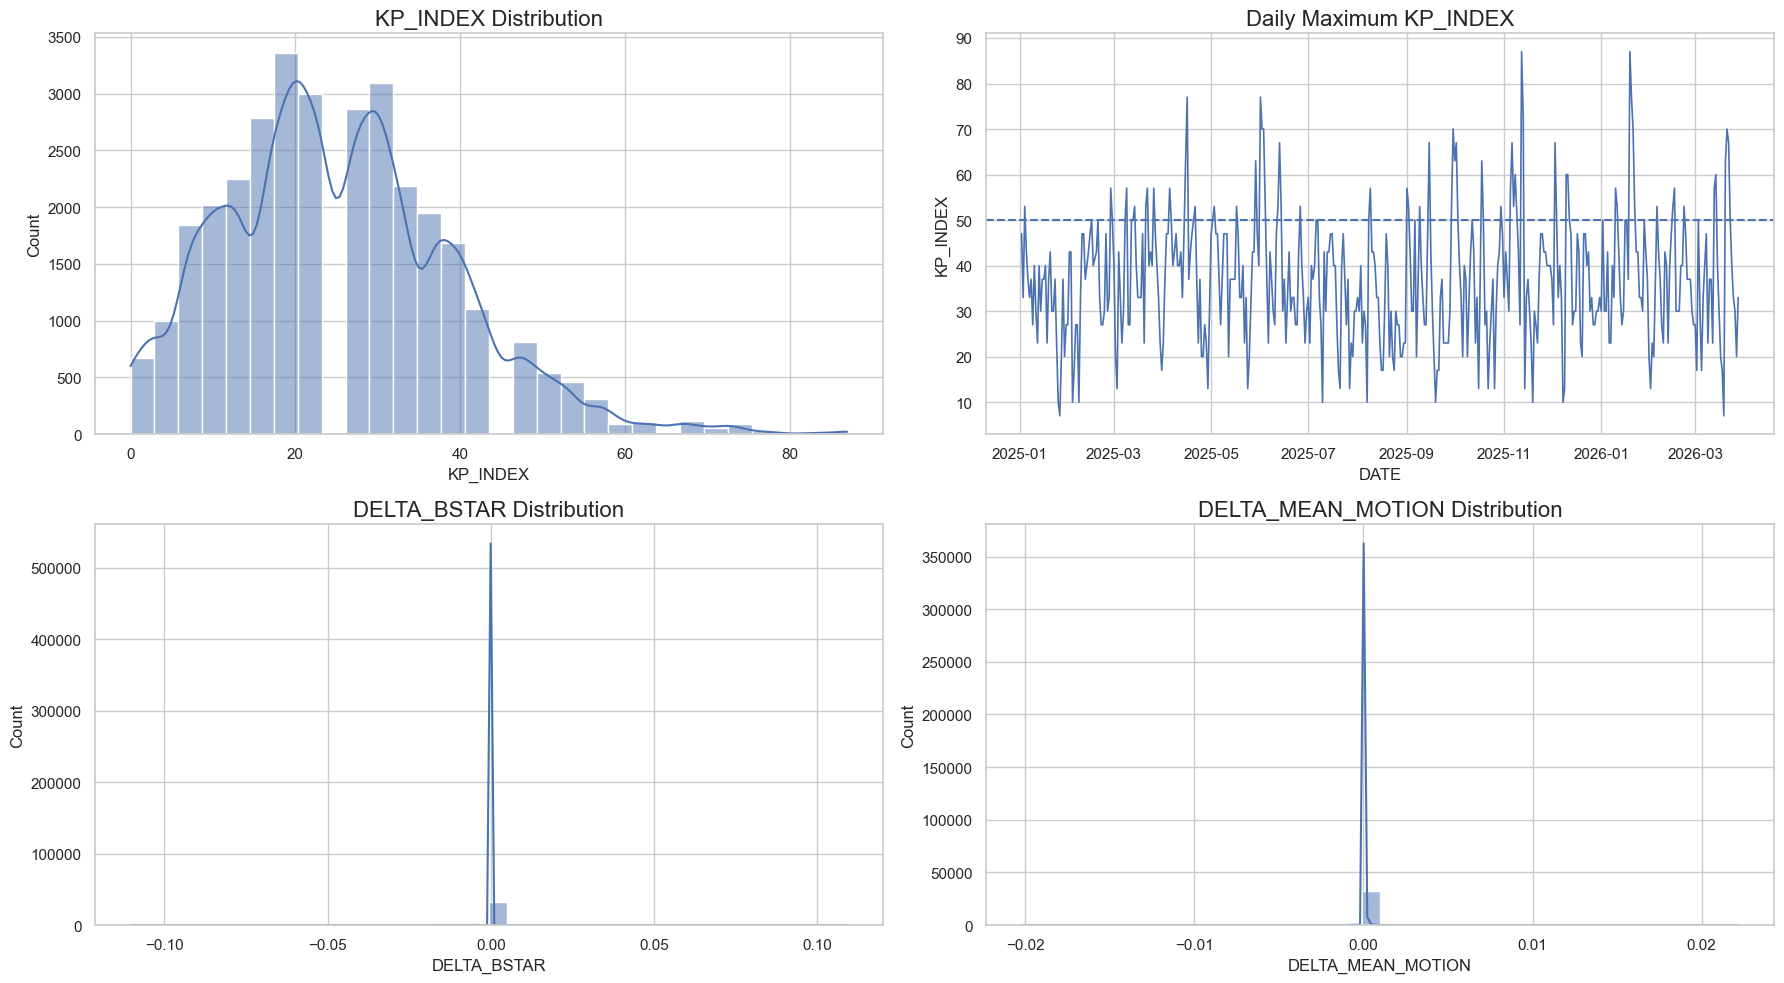

In [14]:
# ---------------------------------------------------------
# EDA 2: Post-feature checks
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

sns.histplot(df_model["KP_INDEX"], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("KP_INDEX Distribution")

daily_max_kp = (
    df_model.groupby(df_model["DATE"].dt.date)["KP_INDEX"]
    .max()
    .reset_index()
)
sns.lineplot(data=daily_max_kp, x="DATE", y="KP_INDEX", ax=axes[0, 1], linewidth=1.2)
axes[0, 1].axhline(50, linestyle="--")
axes[0, 1].set_title("Daily Maximum KP_INDEX")

sns.histplot(df_model["DELTA_BSTAR"].dropna(), bins=40, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("DELTA_BSTAR Distribution")

sns.histplot(df_model["DELTA_MEAN_MOTION"].dropna(), bins=40, kde=True, ax=axes[1, 1])
axes[1, 1].set_title("DELTA_MEAN_MOTION Distribution")

plt.tight_layout()
plt.show()

In [15]:
# Keep internal consistency
df_model_export = df_model.copy()

# Add standard field without breaking pipeline
df_model_export["NORAD_CAT_ID"] = df_model_export["NORAD_ID"]

df_model_export.to_csv(engineered_train_path, index=False)

print("Training dataset saved successfully:")
print(f"Training dataset : {engineered_train_path}")

Training dataset saved successfully:
Training dataset : C:\Users\DELL\Desktop\astro\data\processed\ALAZ_Engineered_Training_Data.csv


In [16]:
print("=" * 60)
print("ALAZ FEATURE ENGINEERING PIPELINE COMPLETED SUCCESSFULLY")
print("=" * 60)

print("\nTraining preview:")
display(df_model.head())

ALAZ FEATURE ENGINEERING PIPELINE COMPLETED SUCCESSFULLY

Training preview:


,SAT_NAME,NORAD_ID,EPOCH,DATE,BSTAR,MEAN_MOTION,PERIOD,KP_INDEX,ISN,F10.7_OBS,...,IS_WEEKEND,DOY_SIN,DOY_COS,HOUR_SIN,HOUR_COS,TARGET_NEXT_DELTA_BSTAR,TARGET_NEXT_DELTA_MEAN_MOTION,TARGET_BSTAR_UP,TARGET_MM_DROP,TARGET_ORBITAL_RESPONSE
0,TURKSAT 1B,23200,2025-01-02 03:33:23.222880,2025-01-02,0.0,0.990462,2,20.0,187.0,212.4,...,0,0.034398,0.999408,0.707107,0.707107,0.0,4.430000e-06,0.0,0.0,0.0
1,TURKSAT 1B,23200,2025-01-03 13:55:36.317280,2025-01-03,0.0,0.990466,5,7.0,199.0,199.9,...,0,0.051584,0.998669,-0.258819,-0.965926,0.0,1.000000e-07,0.0,0.0,0.0
2,TURKSAT 1B,23200,2025-01-03 15:43:07.616928,2025-01-03,0.0,0.990466,6,13.0,199.0,199.9,...,0,0.051584,0.998669,-0.707107,-0.707107,0.0,3.740000e-06,0.0,0.0,0.0
3,TURKSAT 1B,23200,2025-01-04 13:50:15.190080,2025-01-04,0.0,0.990470,5,33.0,211.0,209.3,...,1,0.068755,0.997634,-0.258819,-0.965926,0.0,4.500000e-07,0.0,0.0,0.0
4,TURKSAT 1B,23200,2025-01-04 15:31:44.751936,2025-01-04,0.0,0.990471,6,43.0,211.0,209.3,...,1,0.068755,0.997634,-0.707107,-0.707107,0.0,2.920000e-06,0.0,0.0,0.0
